# Analisis Data & Pemodelan Spotify Tracks

Proyek ini menganalisis dataset Spotify Tracks untuk mengeksplorasi karakteristik audio lagu, mengelompokkan jenis musik (clustering), serta memprediksi popularitas lagu berdasarkan fitur audionya.

### Tujuan Proyek:
1. **Data Preprocessing**: Melakukan pembersihan data dari nilai kosong dan duplikasi lagu berdasarkan `track_id`.
2. **Exploratory Data Analysis (EDA)**: Menganalisis distribusi popularitas serta hubungan korelasi antar fitur audio.
3. **Genre Analysis**: Mengidentifikasi genre terpopuler serta karakteristik uniknya.
4. **Clustering (K-Means)**: Mengelompokkan lagu menggunakan K-Means berdasarkan fitur audio intrinsik.
5. **Predictive Modeling**: Membangun model Random Forest Regressor untuk memprediksi popularitas lagu.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import os

# Membuat direktori images untuk menyimpan hasil visualisasi
os.makedirs('images', exist_ok=True)

# Konfigurasi visualisasi
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12


## 1. Data Preparation & Cleaning
Memuat dataset, menghapus kolom indeks yang tidak digunakan, serta membersihkan nilai kosong dan baris duplikat berdasarkan ID lagu (`track_id`) untuk memastikan validitas analisis.


In [2]:
# Memuat data
df = pd.read_csv('data/dataset.csv')

# Menghapus kolom indeks bawaan jika terdeteksi
if df.columns[0] == 'Unnamed: 0' or df.columns[0] == '':
    df = df.iloc[:, 1:]
elif df.columns[0].startswith(','):
    df = df.rename(columns={df.columns[0]: 'index'})
    df = df.drop(columns=['index'])

# Menampilkan informasi dasar dataset
print("Informasi dasar dataset:")
df.info()


Informasi dasar dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          114000 non-null  object 
 1   artists           113999 non-null  object 
 2   album_name        113999 non-null  object 
 3   track_name        113999 non-null  object 
 4   popularity        114000 non-null  int64  
 5   duration_ms       114000 non-null  int64  
 6   explicit          114000 non-null  bool   
 7   danceability      114000 non-null  float64
 8   energy            114000 non-null  float64
 9   key               114000 non-null  int64  
 10  loudness          114000 non-null  float64
 11  mode              114000 non-null  int64  
 12  speechiness       114000 non-null  float64
 13  acousticness      114000 non-null  float64
 14  instrumentalness  114000 non-null  float64
 15  liveness          114000 non-null  float64


In [3]:
# Memeriksa data kosong (missing values)
print("Jumlah missing values per kolom:")
print(df.isnull().sum())

# Menghapus data kosong
df = df.dropna()

# Menghapus duplikasi berdasarkan track_id
print(f"\nJumlah data sebelum pembersihan duplikat: {len(df)}")
df = df.drop_duplicates(subset=['track_id'])
print(f"Jumlah data setelah pembersihan duplikat: {len(df)}")


Jumlah missing values per kolom:
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

Jumlah data sebelum pembersihan duplikat: 113999
Jumlah data setelah pembersihan duplikat: 89740


## 2. Exploratory Data Analysis (EDA)
Menganalisis distribusi tingkat popularitas lagu serta hubungan korelasi antar fitur audio.


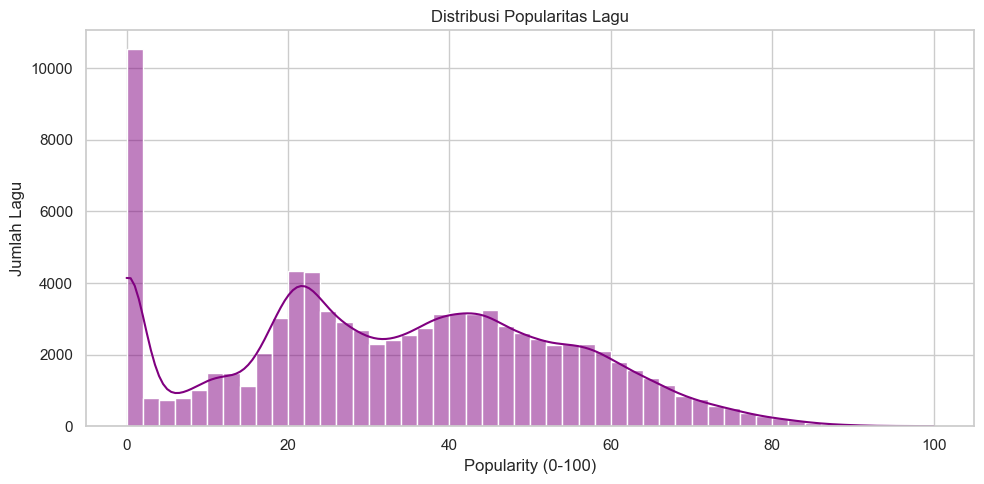

In [4]:
# Visualisasi distribusi popularitas lagu
plt.figure(figsize=(10, 5))
sns.histplot(df['popularity'], bins=50, kde=True, color='purple')
plt.title('Distribusi Popularitas Lagu')
plt.xlabel('Popularity (0-100)')
plt.ylabel('Jumlah Lagu')
plt.tight_layout()
plt.savefig('images/popularity_distribution.png', dpi=300)
plt.show()


### Korelasi Antar Fitur Audio
Visualisasi heatmap untuk mengidentifikasi kekuatan hubungan linear antara berbagai fitur audio.


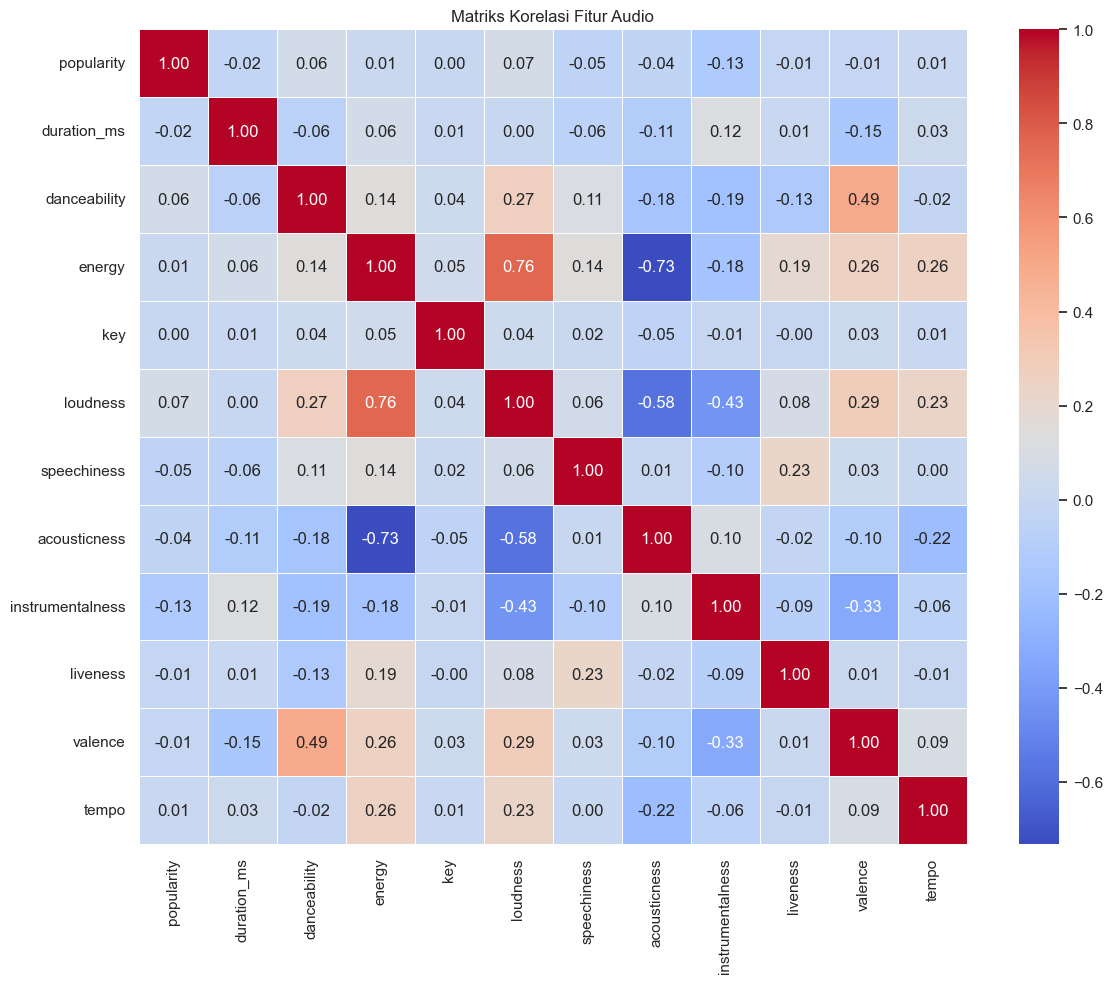

In [5]:
# Memilih fitur audio utama
audio_features = ['popularity', 'duration_ms', 'danceability', 'energy', 'key', 
                  'loudness', 'speechiness', 'acousticness', 'instrumentalness', 
                  'liveness', 'valence', 'tempo']

corr_matrix = df[audio_features].corr()

# Plot Heatmap Korelasi
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriks Korelasi Fitur Audio')
plt.tight_layout()
plt.savefig('images/correlation_matrix.png', dpi=300)
plt.show()


### Hubungan Antara Energy vs. Loudness
Visualisasi menggunakan sampel 5.000 lagu untuk melihat hubungan positif yang kuat antara tingkat energi (`energy`) dan kenyaringan suara (`loudness`).


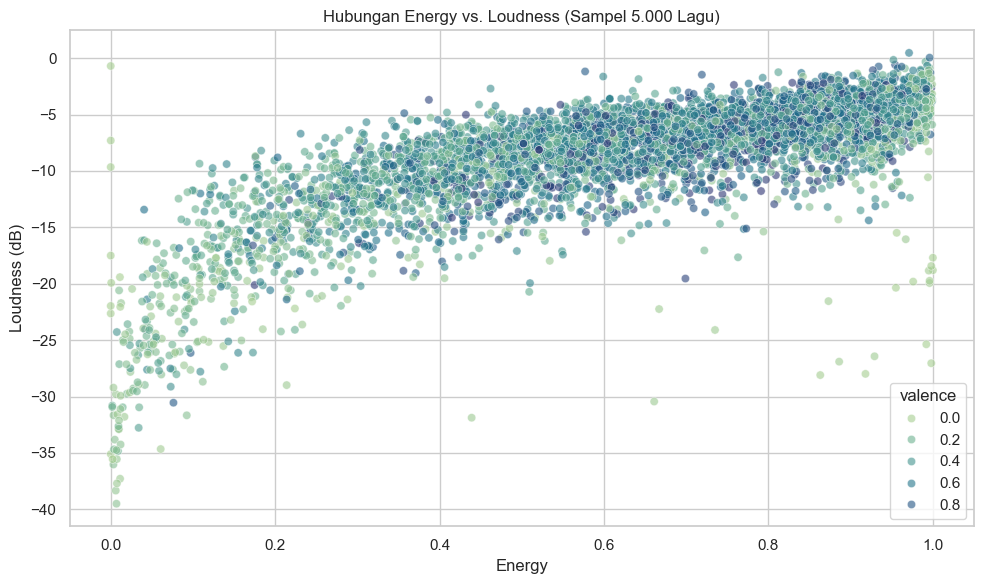

In [6]:
# Mengambil sampel 5000 lagu agar plot lebih representatif dan rapi
sample_df = df.sample(5000, random_state=42)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=sample_df, x='energy', y='loudness', alpha=0.6, hue='valence', palette='crest')
plt.title('Hubungan Energy vs. Loudness (Sampel 5.000 Lagu)')
plt.xlabel('Energy')
plt.ylabel('Loudness (dB)')
plt.tight_layout()
plt.savefig('images/energy_vs_loudness.png', dpi=300)
plt.show()


## 3. Analisis Berdasarkan Genre
Menganalisis 10 genre dengan rata-rata popularitas tertinggi (minimal 100 lagu per genre) serta membandingkan sebaran tingkat *danceability* pada beberapa genre utama.


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_4372\2790634960.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_genres, x='avg_popularity', y='track_genre', palette='viridis')


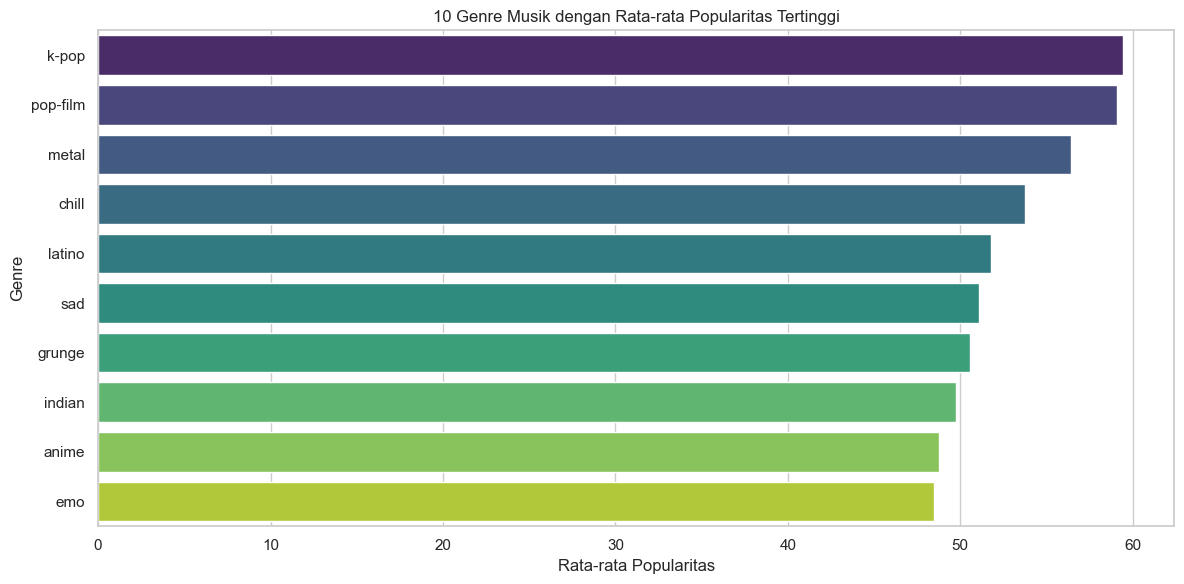

In [7]:
# Menghitung rata-rata popularitas per genre
genre_stats = df.groupby('track_genre').agg(
    avg_popularity=('popularity', 'mean'),
    song_count=('popularity', 'count')
).reset_index()

# Memfilter genre dengan jumlah lagu >= 100
top_genres = genre_stats[genre_stats['song_count'] >= 100].sort_values(by='avg_popularity', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_genres, x='avg_popularity', y='track_genre', palette='viridis')
plt.title('10 Genre Musik dengan Rata-rata Popularitas Tertinggi')
plt.xlabel('Rata-rata Popularitas')
plt.ylabel('Genre')
plt.tight_layout()
plt.savefig('images/top_genres_popularity.png', dpi=300)
plt.show()


### Distribusi Danceability Lintas Genre
Membandingkan variasi tingkat *danceability* pada genre `pop`, `rock`, `classical`, `hip-hop`, dan `metal` menggunakan Boxplot.


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_4372\466943404.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_filtered, x='track_genre', y='danceability', palette='Set2')


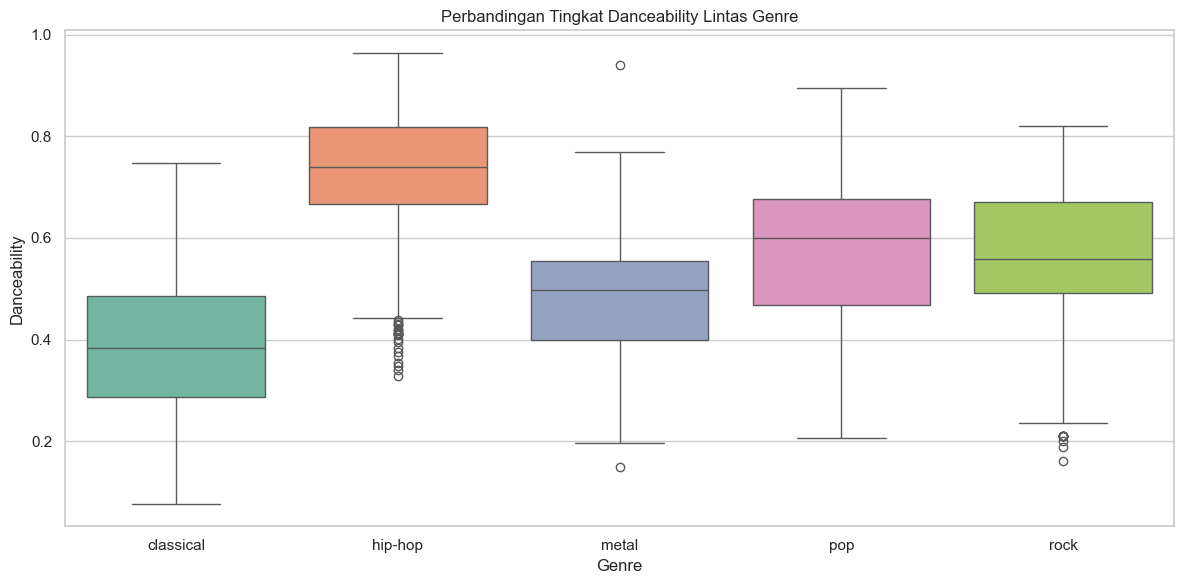

In [8]:
selected_genres = ['pop', 'rock', 'classical', 'hip-hop', 'metal']
df_filtered = df[df['track_genre'].isin(selected_genres)]

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_filtered, x='track_genre', y='danceability', palette='Set2')
plt.title('Perbandingan Tingkat Danceability Lintas Genre')
plt.xlabel('Genre')
plt.ylabel('Danceability')
plt.tight_layout()
plt.savefig('images/genre_danceability.png', dpi=300)
plt.show()


## 4. Clustering Lagu Menggunakan K-Means
Mengelompokkan lagu ke dalam 4 cluster berdasarkan kombinasi fitur audio: `danceability`, `energy`, `acousticness`, `instrumentalness`, dan `valence`.


In [9]:
# Seleksi fitur untuk clustering
cluster_features = ['danceability', 'energy', 'acousticness', 'instrumentalness', 'valence']
X_cluster = df[cluster_features]

# Standardisasi fitur
scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster)

# Inisialisasi dan fitting K-Means
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['music_cluster'] = kmeans.fit_predict(X_cluster_scaled)

# Menampilkan profil rata-rata tiap cluster
cluster_profile = df.groupby('music_cluster')[cluster_features].mean()
print("Profil karakteristik rata-rata tiap cluster:")
print(cluster_profile)


Profil karakteristik rata-rata tiap cluster:
               danceability    energy  acousticness  instrumentalness  \
music_cluster                                                           
0                  0.687252  0.728369      0.215645          0.057509   
1                  0.484482  0.810944      0.055516          0.244829   
2                  0.516339  0.393749      0.704366          0.017702   
3                  0.398144  0.234681      0.791620          0.845812   

                valence  
music_cluster            
0              0.705063  
1              0.301360  
2              0.390162  
3              0.218038  


### Karakteristik Tiap Cluster:
* **Cluster 0 (Acoustic/Slow)**: Didominasi oleh lagu-lagu dengan tingkat *acousticness* tinggi dan energi yang rendah.
* **Cluster 1 (Dance/Party)**: Didominasi oleh lagu-lagu dengan tingkat *energy*, *danceability*, dan *valence* (keceriaan) yang tinggi.
* **Cluster 2 (Instrumental/Ambient)**: Didominasi oleh lagu-lagu instrumental dengan tingkat *instrumentalness* tinggi.
* **Cluster 3 (Modern Pop/Rock)**: Lagu dengan tingkat energi tinggi namun memiliki *acousticness* yang rendah.

Berikut visualisasi sebaran cluster menggunakan fitur `danceability` vs `acousticness`.


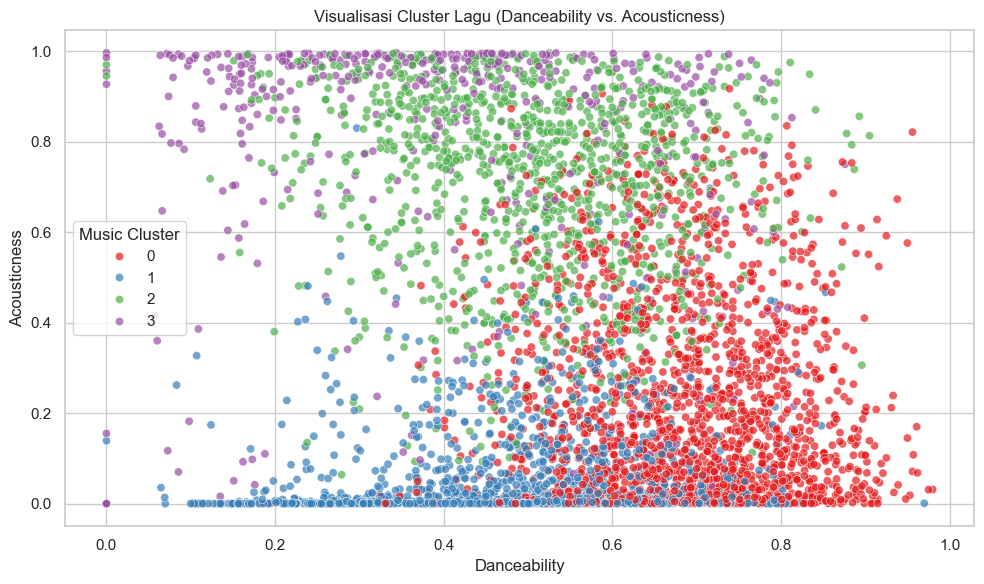

In [10]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df.sample(5000, random_state=42), x='danceability', y='acousticness', hue='music_cluster', palette='Set1', alpha=0.7)
plt.title('Visualisasi Cluster Lagu (Danceability vs. Acousticness)')
plt.xlabel('Danceability')
plt.ylabel('Acousticness')
plt.legend(title='Music Cluster')
plt.tight_layout()
plt.savefig('images/spotify_clusters.png', dpi=300)
plt.show()


## 5. Prediksi Popularitas Menggunakan Random Forest
Membangun model regresi menggunakan Random Forest Regressor untuk memprediksi tingkat popularitas lagu berdasarkan fitur audionya.


In [11]:
# Menentukan fitur X dan target y
prediction_features = ['duration_ms', 'danceability', 'energy', 'key', 'loudness', 
                       'mode', 'speechiness', 'acousticness', 'instrumentalness', 
                       'liveness', 'valence', 'tempo']
X = df[prediction_features]
y = df['popularity']

# Splitting data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardisasi fitur
scaler_pred = StandardScaler()
X_train_scaled = scaler_pred.fit_transform(X_train)
X_test_scaled = scaler_pred.transform(X_test)

# Pelatihan model Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=50, max_depth=12, random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)

# Prediksi model
y_pred = rf_model.predict(X_test_scaled)

# Evaluasi performa model
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Hasil Evaluasi Model:")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2 Score: {r2:.4f}")


Hasil Evaluasi Model:
MSE: 353.52
RMSE: 18.80
R2 Score: 0.1547


### Analisis Feature Importance
Visualisasi kontribusi masing-masing fitur audio terhadap keputusan model dalam memprediksi popularitas lagu.


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_4372\1882918507.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_ranking, x='Importance', y='Fitur', palette='viridis')


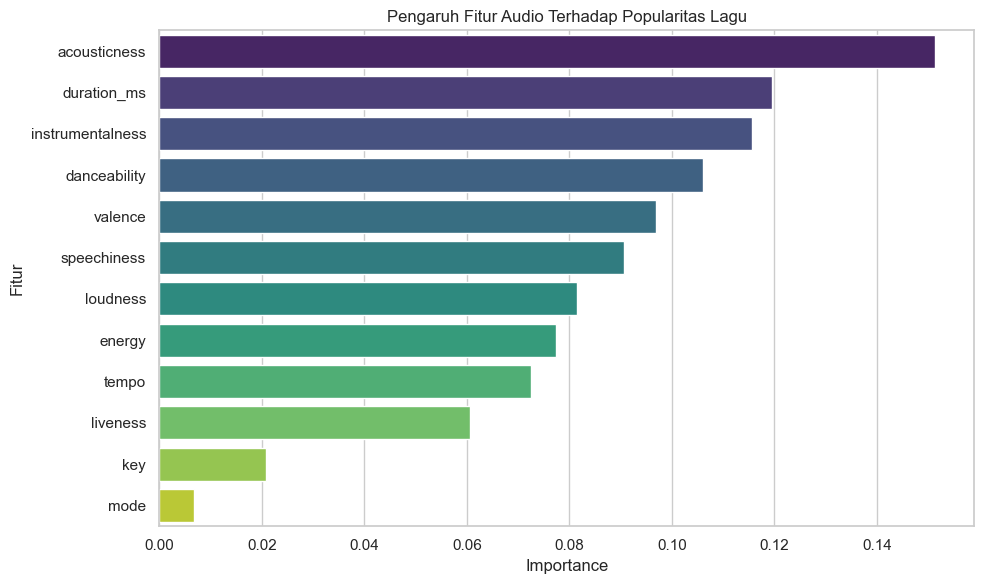

In [12]:
# Menghitung feature importance
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

feature_ranking = pd.DataFrame({
    'Fitur': [prediction_features[i] for i in indices],
    'Importance': importances[indices]
})

# Visualisasi Feature Importance
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_ranking, x='Importance', y='Fitur', palette='viridis')
plt.title('Pengaruh Fitur Audio Terhadap Popularitas Lagu')
plt.xlabel('Importance')
plt.ylabel('Fitur')
plt.tight_layout()
plt.savefig('images/feature_importances.png', dpi=300)
plt.show()
